Mounted at /content/drive
=== STRUTTURA (primo livello di 'dataset/') ===
  - battery
  - clothing
  - glass
  - metal
  - organic
  - papery
  - plastic
  - undifferentiated

=== IMMAGINI PER CLASSE ===
  clothing               7302  ( 47.1%)
  glass                  2011  ( 13.0%)
  papery                 1941  ( 12.5%)
  organic                 985  (  6.3%)
  battery                 945  (  6.1%)
  plastic                 865  (  5.6%)
  metal                   769  (  5.0%)
  undifferentiated        697  (  4.5%)
  TOTALE                15515

Sbilanciamento (max/min): 10.5x  (max=7302, min=697)

=== ANALISI IMMAGINI (campione casuale) ===
Larghezza:  min=137  mediana=368  max=865
Altezza:    min=112  mediana=348  max=772
Aspect ratio (w/h):  min=0.37  mediana=1.00  max=4.02
Modalita' colore: {'RGB': 500}
Formati file: {'JPEG': 500}
Immagini non-RGB o problematiche (su 500 campionate): 0



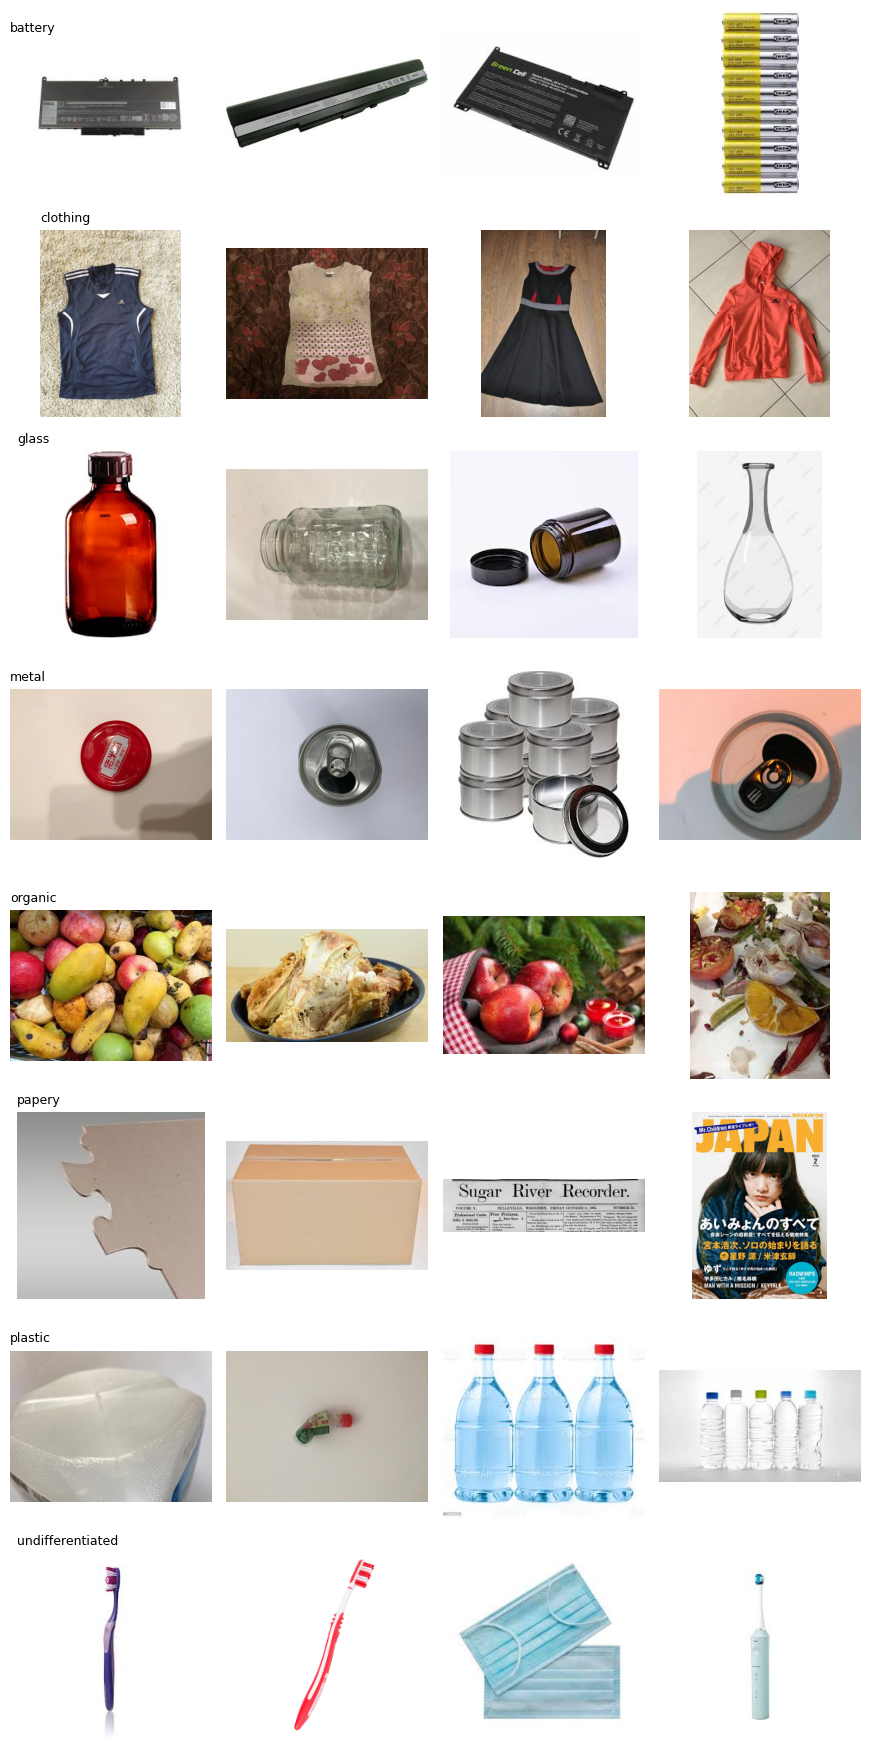

In [1]:
"""
Waste Type Identification - Analisi Esplorativa del Dataset (EDA)
-----------------------------------------------------------------
"""

import os
import random
import statistics as st
from pathlib import Path
from collections import Counter

from PIL import Image
import matplotlib.pyplot as plt

# Monta il Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print("Mount Drive non eseguito:", e)

# Percorso della cartella dataset
DATASET_DIR = Path('/content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/dataset')
assert DATASET_DIR.exists(), f"Percorso non trovato: {DATASET_DIR}"

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff', '.gif'}        # Tutte le estensioni possibili per le immagini del DataSet

# Data una cartella, restituisce la lista di tutte le immagini contenute in tale cartella
def list_images(folder: Path):
    return [p for p in folder.rglob('*') if p.suffix.lower() in IMG_EXTS]

# Struttura delle cartelle (primo livello)
print("=== STRUTTURA (primo livello di 'dataset/') ===")
subdirs = sorted([p for p in DATASET_DIR.iterdir() if p.is_dir()])              # Ordina le sottocartelle

# Stampa tutte le sottocartelle (ordinate in ordine alfabetico per nome)
for d in subdirs:
    print("  -", d.name)
print()

# Conteggio immagini per classe (per capire lo sbilanciamento)
print("=== IMMAGINI PER CLASSE ===")
class_counts = {}
all_images = []
for d in subdirs:
    imgs = list_images(d)                                   # Ottiene tutte le immagini di quella directory
    class_counts[d.name] = len(imgs)                        # Conta il numero di immagini in quella cartella
    all_images.extend((d.name, p) for p in imgs)

total = sum(class_counts.values())                          # Somma tutte le immagini, per ottenere il numero totale di immagini di tutto il DataSet

# Stampa per ciascuna directory il numero di immagini, con la rispettiva percentuale rispetto all'intero DataSet
for cls, n in sorted(class_counts.items(), key=lambda x: -x[1]):
    pct = 100 * n / total if total else 0
    print(f"  {cls:20s} {n:6d}  ({pct:5.1f}%)")
print(f"  {'TOTALE':20s} {total:6d}")

# Mostra lo sbilanciamento presente, ovvero il rapporto tra il numero massimo di immagini e il numero minimo di immagini che ciascuna classe (cartella) contiene
if class_counts and min(class_counts.values()) > 0:
    mx, mn = max(class_counts.values()), min(class_counts.values())
    print(f"\nSbilanciamento (max/min): {mx/mn:.1f}x  (max={mx}, min={mn})")
print()

# Risoluzioni, formati, modalita' colore (su un campione)
print("=== ANALISI IMMAGINI (campione casuale) ===")
sample = random.sample(all_images, min(500, len(all_images)))                   # Campiona 500 immagini
widths, heights = [], []
modes, formats = Counter(), Counter()
problems = []
for cls, p in sample:
    try:
        with Image.open(p) as im:
            widths.append(im.width)                                             # Estrae la larghezza
            heights.append(im.height)                                           # Estrae l'altezza
            modes[im.mode] += 1
            formats[im.format or p.suffix.lower()] += 1
            if im.mode != 'RGB':                                                # grayscale / RGBA / palette
                problems.append((p.name, im.mode))
    except Exception as e:
        problems.append((p.name, f"ERRORE: {e}"))

# Stampa larghezza e altezza min/max, con la relativa mediana su tutti i 500 campioni
if widths:
    print(f"Larghezza:  min={min(widths)}  mediana={int(st.median(widths))}  max={max(widths)}")
    print(f"Altezza:    min={min(heights)}  mediana={int(st.median(heights))}  max={max(heights)}")
    ar = [w / h for w, h in zip(widths, heights)]
    print(f"Aspect ratio (w/h):  min={min(ar):.2f}  mediana={st.median(ar):.2f}  max={max(ar):.2f}")        # Stampa il minimo, il massimo e la mediana dell'AR (rapporto tra le larghezze e le altezze)

print("Modalita' colore:", dict(modes))                                         # grayscale / RGBA / palette
print("Formati file:", dict(formats))                                           # Formato di tutte le immagini
print(f"Immagini non-RGB o problematiche (su {len(sample)} campionate): {len(problems)}")
# Stampa eventuali problemi riscontrati
for name, info in problems[:10]:
    print("   !", name, "->", info)
print()

# Griglia di esempi per classe (controllo visivo)
# Stampa 4 campioni casuali per ciascuna classe
n_per_class = 4
rows = max(len(subdirs), 1)
fig, axes = plt.subplots(rows, n_per_class, figsize=(n_per_class * 2.2, rows * 2.2))

for i, d in enumerate(subdirs):
    imgs = list_images(d)
    picks = random.sample(imgs, min(n_per_class, len(imgs)))                    # Estrae, per quella determinata classe, 4 campioni casuali
    # Mostra ciascuna immagine
    for j in range(n_per_class):
        ax = axes[i][j] if rows > 1 else axes[j]
        ax.axis('off')
        if j < len(picks):
            try:
                ax.imshow(Image.open(picks[j]).convert('RGB'))
            except Exception:
                pass
        if j == 0:
            ax.set_title(d.name, fontsize=9, loc='left')
plt.tight_layout()
plt.show()